In [18]:
## Instalação e Preparação do Ambiente


!pip install -q kaggle
!pip install -q -U efficientnet
!pip install -q scikit-learn
!pip install -q gradio

import csv
import os
import zipfile
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import efficientnet.tfkeras as efn

In [3]:
## Download Automático do Dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000
with zipfile.ZipFile("skin-cancer-mnist-ham10000.zip", 'r') as zip_ref:
    zip_ref.extractall("dermascan_data")

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0


In [8]:
csv_path = "dermascan_data/HAM10000_metadata.csv"
csv_path_filtered = "dermascan_data/HAM10000_metadata_filtered.csv"
imagens_dir_1 = "dermascan_data/ham10000_images_part_1"
imagens_dir_2 = "dermascan_data/ham10000_images_part_2"

# Carregar o CSV
df = pd.read_csv(csv_path)

# Lista de doenças para excluir
doencas_excluir = ['bcc', 'akiec', 'vasc', 'df']

# Filtra o DataFrame para as linhas que serão excluídas
linhas_excluir = df[df.iloc[:, 2].isin(doencas_excluir)]

# Apaga as imagens correspondentes
for nome_imagem in linhas_excluir.iloc[:, 1]:
    caminho_imagem_1 = os.path.join(imagens_dir_1, f"{nome_imagem}.jpg")
    caminho_imagem_2 = os.path.join(imagens_dir_2, f"{nome_imagem}.jpg")
    if os.path.exists(caminho_imagem_1):
        os.remove(caminho_imagem_1)
        print(f"Imagem removida: {caminho_imagem_1}")
    elif os.path.exists(caminho_imagem_2):
        os.remove(caminho_imagem_2)
        print(f"Imagem removida: {caminho_imagem_2}")
    else:
        print(f"Imagem não encontrada: {caminho_imagem_1, caminho_imagem_2}")

with open(csv_path, newline='', encoding='utf-8') as csv_in, \
     open(csv_path_filtered, 'w', newline='', encoding='utf-8') as csv_out:

    leitor = csv.reader(csv_in)
    escritor = csv.writer(csv_out)

    for linha in leitor:
        # Pula linhas onde a coluna C (índice 2) está na lista de doenças
        if linha[2] not in doencas_excluir:
            escritor.writerow(linha)

!mv dermascan_data/HAM10000_metadata_filtered.csv dermascan_data/HAM10000_metadata.csv
print("Linhas com doenças removidas. Arquivo salvo como:", csv_path_filtered)

Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0029417.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0029915.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0029360.jpg
Imagem removida: dermascan_data/ham10000_images_part_1/ISIC_0026152.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0029659.jpg
Imagem removida: dermascan_data/ham10000_images_part_1/ISIC_0026575.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0030586.jpg
Imagem removida: dermascan_data/ham10000_images_part_1/ISIC_0025178.jpg
Imagem removida: dermascan_data/ham10000_images_part_1/ISIC_0028730.jpg
Imagem removida: dermascan_data/ham10000_images_part_1/ISIC_0029041.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0031040.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0031929.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0032173.jpg
Imagem removida: dermascan_data/ham10000_images_part_2/ISIC_0033

In [9]:
## Pré-processamento dos Dados
df = pd.read_csv("dermascan_data/HAM10000_metadata.csv")
img_dir = "dermascan_data/HAM10000_images_part_1/"
df["path"] = df["image_id"].apply(lambda x: os.path.join("dermascan_data", "HAM10000_images_part_1", f"{x}.jpg"))
df = df[df["path"].apply(os.path.exists)]
df["label"] = df["dx"]
df = df[["path", "label"]]

from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
train_df, val_df = train_test_split(train_df, test_size=0.15, stratify=train_df["label"], random_state=42)
class_names = sorted(train_df["label"].unique())
num_classes = len(class_names)

<ipython-input-9-1c21746b1d06>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = df["dx"]


In [10]:
## Data Augmentation + Data Generators
IMG_SIZE = 300
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(train_df, x_col='path', y_col='label',
                                              target_size=(IMG_SIZE, IMG_SIZE),
                                              class_mode='categorical', batch_size=BATCH_SIZE)

val_gen = val_test_datagen.flow_from_dataframe(val_df, x_col='path', y_col='label',
                                               target_size=(IMG_SIZE, IMG_SIZE),
                                               class_mode='categorical', batch_size=BATCH_SIZE)

test_gen = val_test_datagen.flow_from_dataframe(test_df, x_col='path', y_col='label',
                                                target_size=(IMG_SIZE, IMG_SIZE),
                                                class_mode='categorical', batch_size=BATCH_SIZE, shuffle=False)

Found 3200 validated image filenames belonging to 3 classes.
Found 565 validated image filenames belonging to 3 classes.
Found 665 validated image filenames belonging to 3 classes.


In [11]:
## Modelo EfficientNetB3 com Fine-Tuning + Regularização
base_model = efn.EfficientNetB3(include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3), weights='imagenet')
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax', kernel_regularizer=l2(0.001))(x)

model = Model(inputs=base_model.input, outputs=output)
for layer in base_model.layers:
    layer.trainable = False
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_gen, validation_data=val_gen, epochs=10)

44107200/44107200 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.7196 - loss: 0.7246 - val_accuracy: 0.8000 - val_loss: 0.4886
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 877ms/step - accuracy: 0.7868 - loss: 0.5438 - val_accuracy: 0.8053 - val_loss: 0.4601
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 868ms/step - accuracy: 0.7937 - loss: 0.5081 - val_accuracy: 0.8248 - val_loss: 0.4424
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 873ms/step - accuracy: 0.8087 - loss: 0.5038 - val_accuracy: 0.8177 - val_loss: 0.4379
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 869ms/step - accuracy: 0.8111 - loss: 0.4764 - val_accuracy: 0.8248 - val_loss: 0.4355
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 874ms/step - accuracy: 0.8185 - loss: 0.4551 - val_accuracy: 0.8248 - val_loss: 0.4339
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 874ms/step - accuracy: 0.8044 - loss: 0.4950 - val_accuracy: 0.8336 - val_loss: 0.4309
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 867ms/step - accuracy: 0.8208 - loss: 0.4

In [12]:
## Fine-Tuning
for layer in base_model.layers[-30:]:
    layer.trainable = True
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(train_df["label"]),
                                     y=train_df["label"])
class_weights = dict(zip(np.unique(train_df["label"]), class_weights))

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.2)
]

history_fine = model.fit(train_gen, validation_data=val_gen,
                         epochs=20, callbacks=callbacks,
                         class_weight=class_weights)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6240 - loss: 0.8877 - val_accuracy: 0.8195 - val_loss: 0.4555 - learning_rate: 1.0000e-05
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 99s 883ms/step - accuracy: 0.7834 - loss: 0.5872 - val_accuracy: 0.8177 - val_loss: 0.4542 - learning_rate: 1.0000e-05
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 894ms/step - accuracy: 0.8084 - loss: 0.5188 - val_accuracy: 0.8265 - val_loss: 0.4498 - learning_rate: 1.0000e-05
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 890ms/step - accuracy: 0.7982 - loss: 0.5254 - val_accuracy: 0.8301 - val_loss: 0.4446 - learning_rate: 1.0000e-05
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 89s 894ms/step - accuracy: 0.8044 - loss: 0.5215 - val_accuracy: 0.8301 - val_loss: 0.4388 - learning_rate: 1.0000e-05
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 141s 888ms/step - accuracy: 0.8096 - loss: 0.5055 - val_accuracy: 0.8248 - val_loss: 0.4372 - learning_rate: 1.0000e-05
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 885

In [14]:
## Salvar Modelo Final
model.save("dermascan_model.h5")
model.save("dermascan_model.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


21/21 ━━━━━━━━━━━━━━━━━━━━ 16s 779ms/step - accuracy: 0.8498 - loss: 0.3781

 Acurácia no Teste: 0.8391


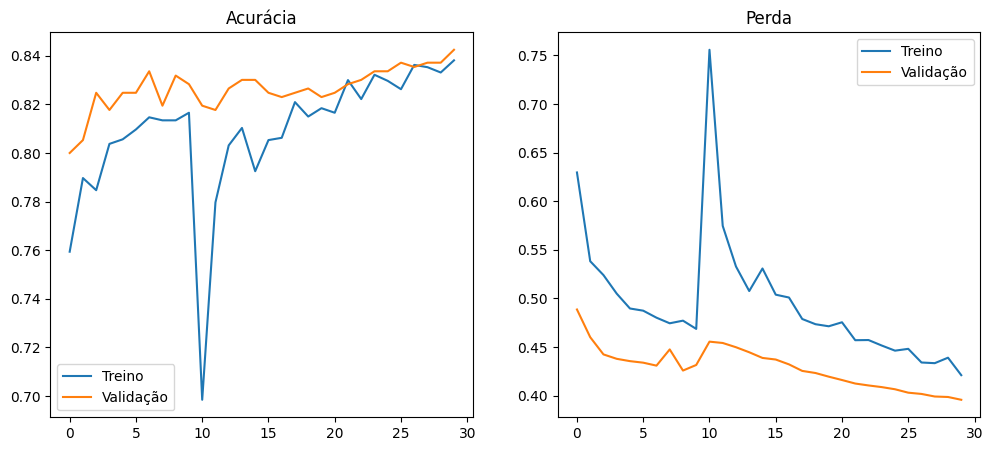

In [15]:
## Avaliação e Gráficos
loss, acc = model.evaluate(test_gen)
print(f"\n Acurácia no Teste: {acc:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'] + history_fine.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'] + history_fine.history['val_accuracy'], label='Validação')
plt.title('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'] + history_fine.history['loss'], label='Treino')
plt.plot(history.history['val_loss'] + history_fine.history['val_loss'], label='Validação')
plt.title('Perda')
plt.legend()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 842ms/step


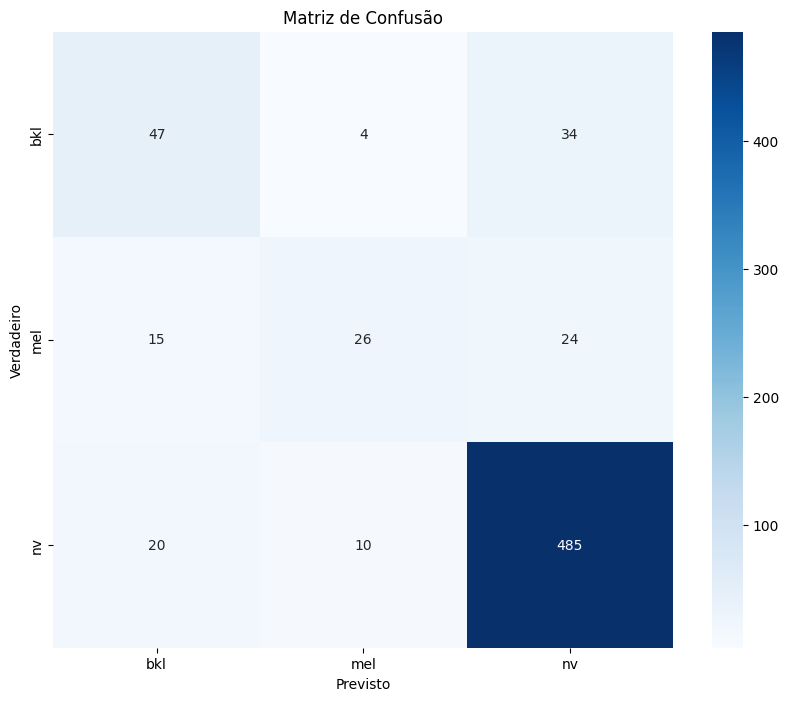


 Relatório de Classificação:

              precision    recall  f1-score   support

         bkl       0.57      0.55      0.56        85
         mel       0.65      0.40      0.50        65
          nv       0.89      0.94      0.92       515

    accuracy                           0.84       665
   macro avg       0.71      0.63      0.66       665
weighted avg       0.83      0.84      0.83       665



In [16]:
## Matriz de Confusão
preds = model.predict(test_gen)
y_true = test_gen.classes
y_pred = np.argmax(preds, axis=1)
labels = list(test_gen.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.title("Matriz de Confusão")
plt.ylabel('Verdadeiro')
plt.xlabel('Previsto')
plt.show()

print("\n Relatório de Classificação:\n")
print(classification_report(y_true, y_pred, target_names=labels))